In [1]:
import pandas as pd
import os
# Default values defined in the notebook for Station and OSVAS install:
OSVAS='/home/alvaro/master/TFM/OSVAS'  # Main OSVAS path
Station_name='Cabauw'

# If an environment variable STATION or OSVAS exists, override the default
Station_name = os.getenv("STATION_NAME", Station_name)
OSVAS = os.getenv("OSVAS", OSVAS)

key_path = os.path.join(OSVAS,"KMNI_token.txt")
api_key = open(key_path, "r").readline().strip()

start_date = pd.to_datetime('2016-01-01 00:00:00', utc=True)
end_date = pd.to_datetime('2020-12-31 23:59:59', utc=True)
print(f"Creating Validation files for: {Station_name} with OSVAS installation in {OSVAS}")

Creating Validation files for: Cabauw with OSVAS installation in /home/alvaro/master/TFM/OSVAS


In [2]:
# Necessary functions
from datetime import date, datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
from functools import reduce
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset, date2num
import numpy as np
import os
import pytz
import re
import requests
import sqlite3
import tempfile
import xarray as xr
import xml.etree.ElementTree as ET
import yaml

def download_file(endpoint, headers, filename, download_directory='./.nc_data'):
    """
        Downloads the file filename from the endpoint to download_directory. If open is set to true, 
        the function returns the opened Netcdf Dataset.

        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token.
            download_directory: The path to the directory where files will be downloaded.
    """
    result = requests.get('/'.join((endpoint, filename, 'url')), headers=headers)
    r = requests.get(result.json()['temporaryDownloadUrl'])
    r.raise_for_status()
    with tempfile.NamedTemporaryFile(suffix=".nc") as f:
        f.write(r.content)
        f.flush()
        ds = xr.open_dataset(f.name)  # or "h5netcdf"
    return ds

def fetch_file_list(endpoint, headers, payload):
    """
        File list returned by endpoint satisfying payload criteria.
        
        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token
            payload: Dictionary with optional parameters for the get request.
        
        return: A list with the filenames that satisfy the given criteria. This filenames can then be retrieved calling another KMNI API endpoint
        
    """
    file_list = []
    truncated = True
    while truncated:
        result = requests.get(endpoint, headers=headers, params=payload)
        result.raise_for_status()
        result = result.json()
        file_list += [i['filename'] for i in result['files']]
        truncated = result['isTruncated']
        if truncated:
            payload += {'nextPageToken': result['nextPageToken']}
    print(f"{len(file_list)} files will be processed")
    return file_list



def retrieve_data(endpoint, start_date, end_date, key):
    """
    Generates a dataset with the data collected from endpoint between start_date and end_date. It requires the api_key parameter 
    to make the requests to the service.
    """
    dataset_name = endpoint.split("/datasets/")[1].split("/")[0]
    dataset_version = endpoint.split("/versions/")[1].split("/")[0]
    start_file = (f"{dataset_name}_{dataset_version}_{start_date:%Y%m}.nc")
    end_file = (f"{dataset_name}_{dataset_version}_{end_date:%Y%m}.nc")
    months = pd.date_range(start=start_date, end=end_date, freq="MS")
    filenames = [f"{dataset_name}_{dataset_version}_{date:%Y%m}.nc" for date in months]
    headers={"Authorization": api_key}
    payload = {
        'maxKeys': '1000',
        'sorting': 'asc',
        'orderBy': 'filename',
        'begin': start_file,
        'end': end_file
    }
    file_list = fetch_file_list(endpoint, headers, payload)
    files = []
    for file in filenames:
        if file in file_list:
            files.append(download_file(endpoint, headers, file).drop_vars('valid_dates'))
        else:
            print(f"⚠️ {file} not found in KMNI service, data for this month will be filled with nan")
    ds_values = xr.concat(files, dim='time', data_vars='minimal').sortby('time')
    ds_values = ds_values.sel(time=slice(start_date.tz_localize(None), end_date.tz_localize(None)))
    return ds_values

In [3]:
# Temperatura y humedad, carga de datos:
doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_heat_lb1_t10/versions/v1.0/files"
temperature = retrieve_data(doi, start_date, end_date, api_key)

60 files will be processed


ConnectionError: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))

In [4]:
doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_water_lb1_t10/versions/v1.1/files"
moisture = retrieve_data(doi, start_date, end_date, api_key)

60 files will be processed


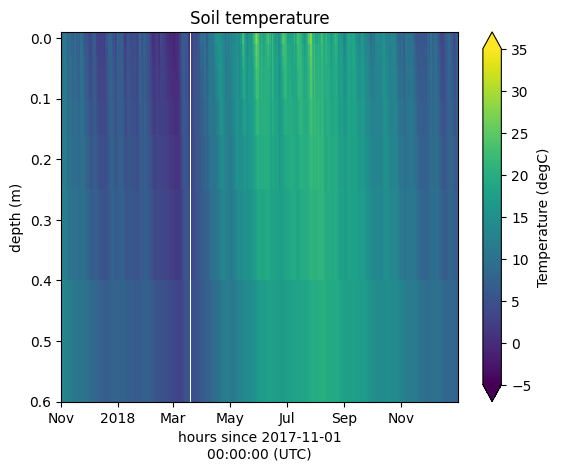

In [180]:
# Prepate temperature dataset (depth,time)
temperature = temperature[[v for v in temperature.data_vars if (v.startswith("TS")) and not (temperature[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in temperature.data_vars]
temp = xr.concat([temperature[v] for v in temperature.data_vars], dim='depth').assign_coords(depth=depth)
temp = temp.sel(time=slice("2017-01-01 00:00:00", "2020-12-13 23:59:59"))
temp.plot(cmap="viridis", cbar_kwargs={"label": "Temperature (degC)"}, extend='both', vmin=-5, vmax=35)
plt.title("Soil temperature")
plt.ylabel("depth (m)")
plt.gca().invert_yaxis()
plt.show()

In [182]:
temp_orig = temp
temp = temp.resample(time='10min').mean()

In [7]:
temp

<xarray.DataArray 'TS00' (depth: 9, time: 207792)> Size: 7MB
array([[2.831711 , 2.8240104, 2.8238297, ..., 6.5731397, 6.577521 ,
        6.580637 ],
       [3.1670492, 3.1533408, 3.1434944, ..., 6.649267 , 6.6506443,
        6.6526995],
       [3.4041283, 3.3941283, 3.3842454, ..., 6.6943536, 6.694647 ,
        6.6958184],
       ...,
       [4.4751387, 4.4750605, 4.476408 , ..., 7.1474895, 7.148505 ,
        7.1492863],
       [5.0991926, 5.0987434, 5.0995054, ..., 7.4867744, 7.4886494,
        7.4895477],
       [6.568514 , 6.5665803, 6.5655255, ..., 8.581432 , 8.58196  ,
        8.5818815]], shape=(9, 207792), dtype=float32)
Coordinates:
  * depth    (depth) float64 72B 0.0 0.02 0.04 0.06 0.08 0.12 0.2 0.3 0.5
  * time     (time) datetime64[ns] 2MB 2017-01-01 ... 2020-12-13T23:50:00.036...
Attributes:
    units:          degC
    long_name:      Soil temperature   0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean

In [218]:
def fit_harmonic(temperature, w):
    """
    Fit a single harmonic: T = T_m + A*cos(omega*t + phi)
    for a (depth, time_coordinate) DataArray or numpy array.
    
    Parameters:
        time_values : 1D array of times (hours of day or day of year)
        data_values : 2D array (time, depth) of temperatures
        omega       : angular frequency in radians per unit of time_values
        
    Returns:
        T_m : 1D array (depth,) mean temperature
        A   : 1D array (depth,) amplitude
        phi : 1D array (depth,) phase in radians
    """
    time_dim = temperature.dims[1]
    
    t = temperature[time_dim].values
    
    # Changing harmonic to Tm + a*cos(wt) + b*sin(wt) with a=Acos(phi) and b=-Asin(phi) for linearity (cosine of the sum identity)
    X = np.column_stack([np.ones_like(t),np.cos(w * t), np.sin(w * t)])
    Y = temperature.values

    T_m = np.full(Y.shape[0], np.nan)
    A   = np.full(Y.shape[0], np.nan)
    phi = np.full(Y.shape[0], np.nan)
    
    for i in range(Y.shape[0]):   # For each depth
        y = Y[i, :]
        mask = ~np.isnan(y)
        if mask.sum() < 3: #Need at least 3 data points
            continue
        beta, *_ = np.linalg.lstsq(X[mask], y[mask], rcond=None) #Linear fit model to data
        tm, a, b = beta

        # Recover coefficients of Tm + A*cos(wt + phi)
        T_m[i] = tm
        A[i]   = np.sqrt(a**2 + b**2)
        phi[i] = np.arctan2(-b, a)

    #Recover DataArray format
    T_m = xr.DataArray(T_m, coords={"depth": temperature.depth})
    A = xr.DataArray(A,   coords={"depth": temperature.depth})
    phi = xr.DataArray(phi, coords={"depth": temperature.depth})
        
    return T_m, A, phi

def compute_decay(amplitude):
    """
    Calculates depth decay constant and amplitude at the surface from the 
    amplitude profile:
    
    A(z) = A0*e(-z/d) => log(A_z) = log(A0) - z/d
    From the linear regression log(A_z) vs. z, d and A0 are calculated
        
    Parameters:
        amplitude (depth): 1D array amplitudes for each depth
        
    Returns:
        d : The decay depth
        A0 : The amplitude at the surface
    """
    log_amp = np.log(amplitude)
    beta = log_amp.polyfit(dim = "depth", deg = 1)
    slope, intercept = beta['polyfit_coefficients'].values
    d = -1/slope
    A0 = np.exp(intercept)
    
    return d, A0

def generate_temperature(depths, times, T_m, A_Y, D_Y, phi_Y, w_Y, A_D, D_D, phi_D, w_D):
    """
    Generate temperature field T(depth, time) based on the analytical solution
    """

    # Build coordinates
    depth = xr.DataArray(depths, dims="depth", coords={"depth": depths})
    time  = xr.DataArray(times, dims="time", coords={"time": times})

    # Extract day-of-year and time-of-day
    doy = time.dt.dayofyear
    tod = time.dt.hour + time.dt.minute/60 + time.dt.second/3600

    # Expand dimensions for broadcasting
    z = depth
    tY = doy
    tD = tod

    # Annual term
    annual = A_Y * np.exp(-z/D_Y) * np.cos(w_Y*tY - z/D_Y + phi_Y)

    # Daily term
    daily = A_D * np.exp(-z/D_D) * np.cos(w_D*tD - z/D_D + phi_D)

    # Total temperature
    T = T_m + annual + daily

    return xr.DataArray(T, dims=("depth","time"), coords={"depth":depths, "time":times})

def compute_heat_equation_solution(data, profile_time, depths, coef = None):
    """
    Generates a temperature profile based on the observations given in 
    data at the depths indicated given by the analytical solution of the 
    heat equation:
    T(z,t) = T_ms + A_De^(-z/D_D)*cos(w_D*t - z/D_D + phi_D) + A_Ye^(-z/D_Y)*cos(w_Y*t - z/D_Y + phi_Y)
    
    Parameters:
        data (depth, time): 2D dataArray containing observed temperature for each depth and time.
        profile_time: 1D array of datetime indicating the moment(s) when the new profile will be calculated
        depths: 1D array of depth where temperature will be computed.
        coef: 1D array the coeffcieints computed in a previous call of the function.
    Returns:
        Tz (depths, times): A 1D array with the temperature profile at the requested depths for the given time.
        coefs: the 1D array of coefficients used [T_m, A_Y, phi_Y, D_Y, w_Y, A_D, phi_D, D_D, w_D]
    """
    if coef is None:
        data.coords["tod"] = data.time.dt.hour + data.time.dt.minute/60
        data.coords["doy"] = data.time.dt.dayofyear

        # Compute daily and anual cycles
        annual_cycle = data.groupby("doy").mean("time") #day of year (day of julian calendar)
        daily_cycle = data.groupby("tod").mean("time") #time of day (in minutes)
        
        #Frequencies of daily and anual cycle
        w_Y = 2*np.pi/365.25
        w_D = 2*np.pi/24

        T_D, A_Dh, phi_D = fit_harmonic(daily_cycle, w_D)
        T_Y, A_Yh, phi_Y = fit_harmonic(annual_cycle, w_Y)
        
        if not np.allclose(T_D, T_Y, .1): #Tm should be the same in both cycles
            print("Warning Mean temperature difference suspiciously large:")
            print("Mean temperatures from daily harmonic:", T_D)
            print("Mean temperatures from annual harmonic:", T_Y)

        #Compute decay constant and surface amplitudes
        d_D, A_D0 = compute_decay(A_Dh)
        d_Y, A_Y0 = compute_decay(A_Yh)
    
        # Show thermal conductivity
        K_D = d_D**2*np.pi/(24*3600)
        K_Y = d_Y**2*np.pi/(24*3600*365.25)
        print("Thermal conductivities calculated daily and annualy (m^2/s):", K_D, K_Y)
        coef = [float(T_Y[0]), A_Y0, d_Y, float(phi_Y[0]), w_Y, A_D0, d_D, float(phi_D[0]), w_D]
    Tz = generate_temperature(depths, profile_time, *coef)
    return coef, Tz

In [219]:
# Test for all temperatures
coef, Tz = compute_heat_equation_solution(temp, temp.time.values, temp.depth)
RMSE = np.sqrt((Tz-temp)**2)
print(coef)
RMSE.mean()

Thermal conductivities calculated daily and annualy (m^2/s): 3.39101009061322e-07 4.35603222631378e-07
[11.812268719205589, np.float64(9.042125988292328), np.float64(2.0918117069234325), 2.8266335202355766, 0.017202423838958484, np.float64(1.2185437451728072), np.float64(0.09657094382351139), 2.4905311649645463, 0.2617993877991494]


<xarray.DataArray ()> Size: 8B
array(1.5196762)
Attributes:
    units:          degC
    long_name:      Soil temperature  0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean

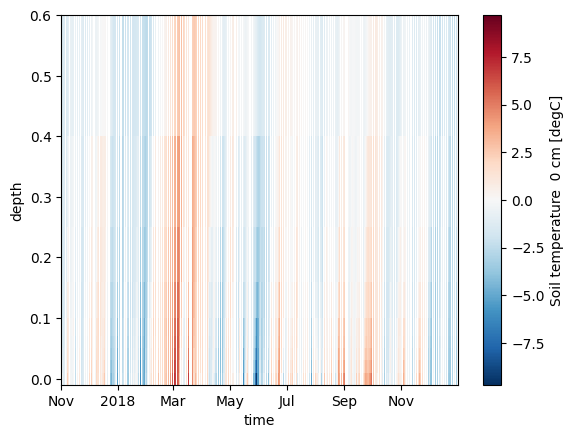

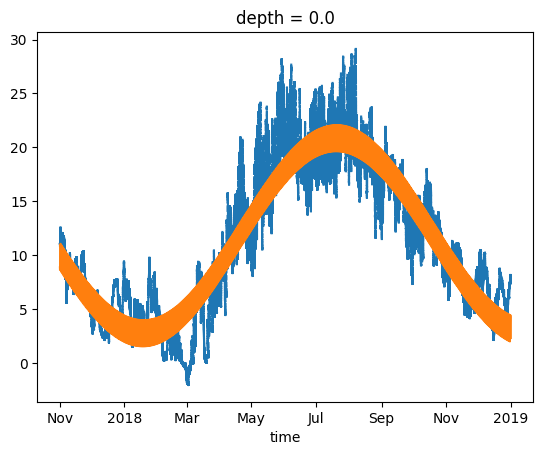

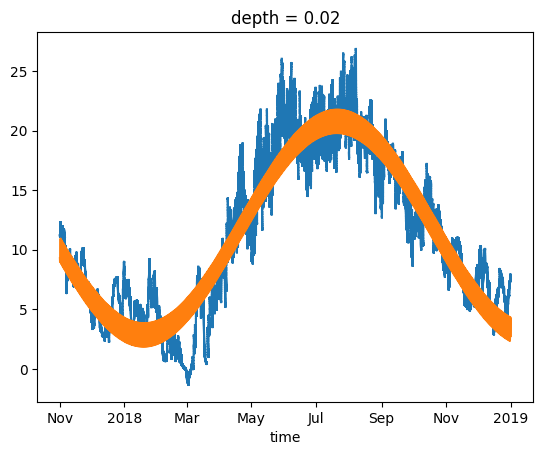

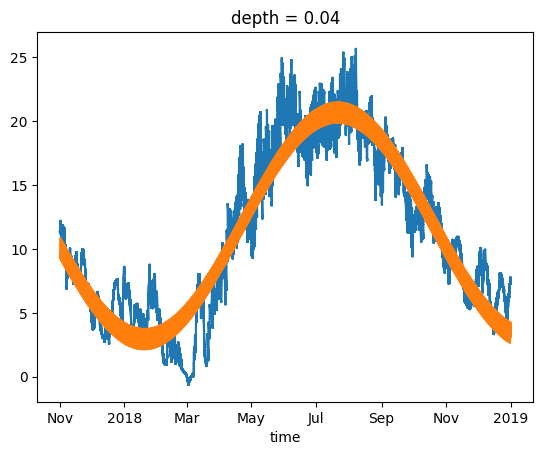

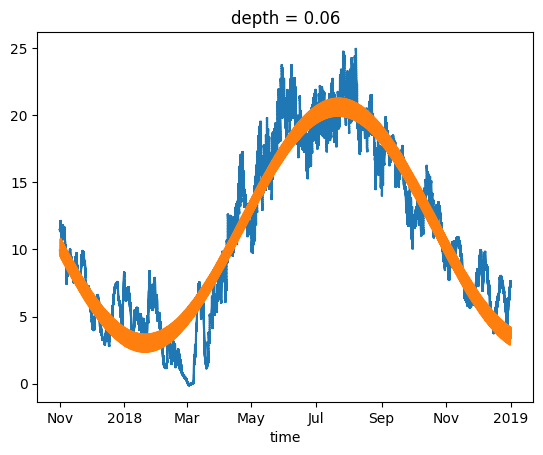

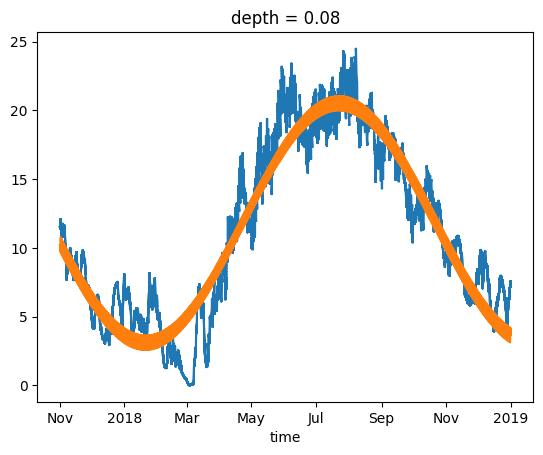

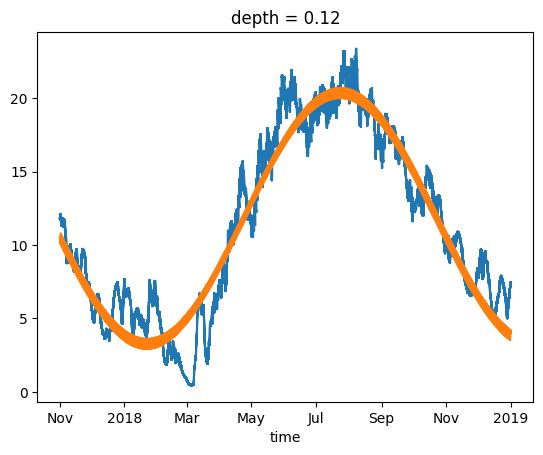

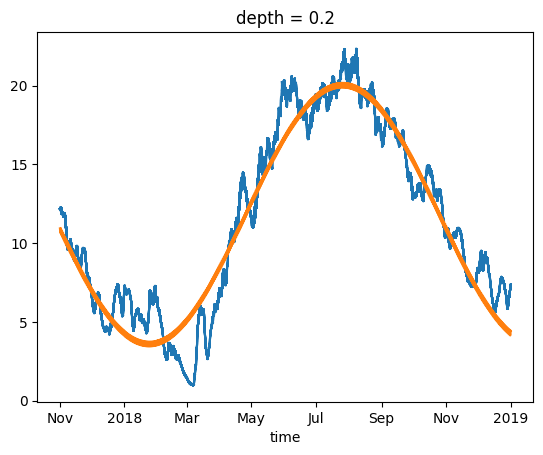

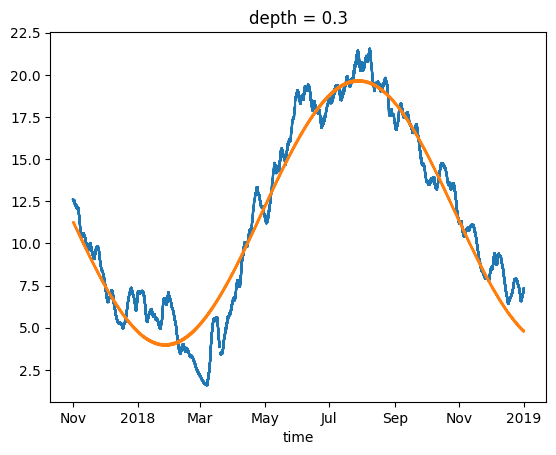

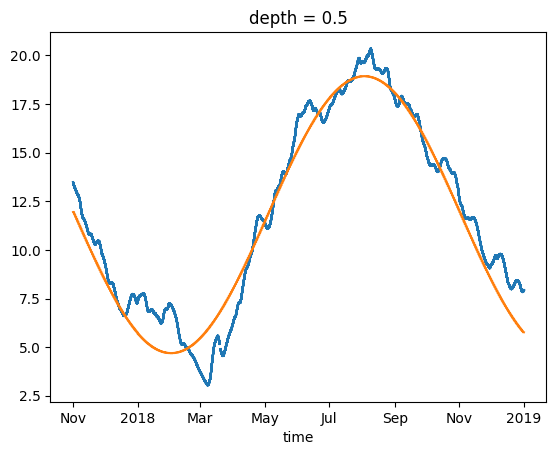

In [220]:
(Tz - temp).plot()
plt.show()
for depth in temp.depth:
    temp.sel(depth = depth).plot()
    Tz.sel(depth = depth).plot()
    plt.show()

In [221]:
# Initialization profile
coef, Tz = compute_heat_equation_solution(temp, [np.datetime64("2017-11-01 00:00:00")], [0.01,0.04,0.10,0.20,0.40,0.60,0.80,1.00,1.50,2.00,3.00,5.00,8.00,12.00], coef)

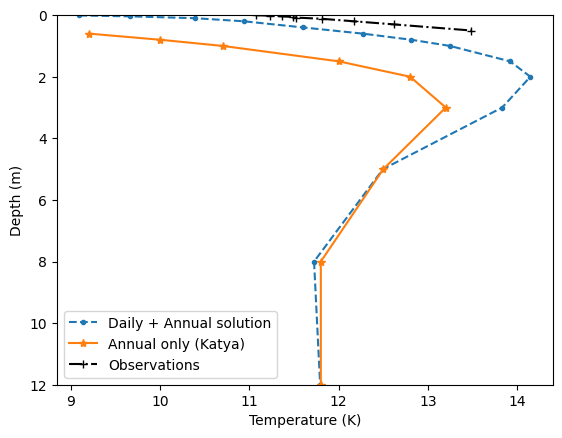

In [222]:
annual = [9.2, 10, 10.7, 12.0, 12.8, 13.2, 12.5, 11.8, 11.8]
plt.plot(Tz, Tz.depth, '.--', label = "Daily + Annual solution")
plt.plot(annual, [.6, .8, 1, 1.5, 2, 3, 5, 8, 12], '*-', label = "Annual only (Katya)")
plt.plot(temp.sel(time = "2017-11-01 00:00:00"), temp.depth, 'k+-.', label = "Observations")
plt.ylabel("Depth (m)")
plt.xlabel("Temperature (K)")
plt.legend()
plt.gca().invert_yaxis
plt.ylim((12,0))
plt.show()

In [10]:
# Initialise using the X*_{SURF/ROOT/DEEP} fields
temp_surf = temp.sel(depth = temp.depth <= 0.05, time=temp.time[0]).mean('depth') + 273.15
temp_root = temp.sel(depth = temp.depth >= 0.05, time=temp.time[0]).mean('depth') + 273.15
temp_deep = temp.sel(depth = temp.depth[-1], time=temp.time[0]) + 273.15
print(temp_surf, temp_root, temp_deep)

<xarray.DataArray 'TS00' ()> Size: 8B
array(276.28429618)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:          degC
    long_name:      Soil temperature   0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean <xarray.DataArray 'TS00' ()> Size: 8B
array(277.70854082)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:          degC
    long_name:      Soil temperature   0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean <xarray.DataArray 'TS00' ()> Size: 4B
array(279.7185, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
    depth    float64 8B 0.5
Attributes:
    units:          degC
    long_name:      Soil temperature   0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean


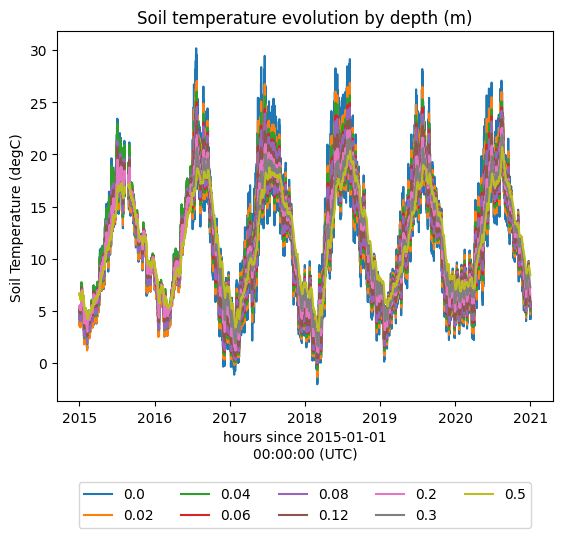

In [8]:
temp.plot.line(x = 'time', hue='depth')
ax = plt.gca()
ax.legend( 
    temp.depth.values, 
    ncol=5,                     # horizontal layout
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2)
)
plt.title("Soil temperature evolution by depth (m)")
plt.ylabel("Soil Temperature (degC)")
plt.show()

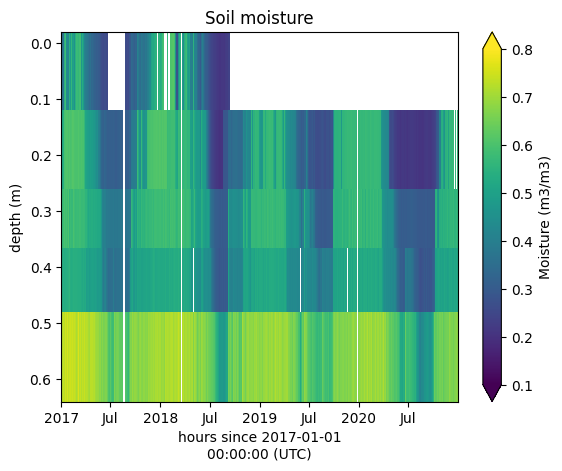

In [40]:
# Prepate temperature dataset (depth,time)
moisture = moisture[[v for v in moisture.data_vars if (v.startswith("TH")) and not (moisture[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in moisture.data_vars]
swc = xr.concat([moisture[v] for v in moisture.data_vars], dim='depth').assign_coords(depth=depth)
swc.sel(depth = swc.depth != 0.03).plot(cmap="viridis", cbar_kwargs={"label": "Moisture (m3/m3)"}, vmin=0.1, vmax=.8, extend='both')
plt.title("Soil moisture")
plt.ylabel("depth (m)")
plt.gca().invert_yaxis()
plt.show()

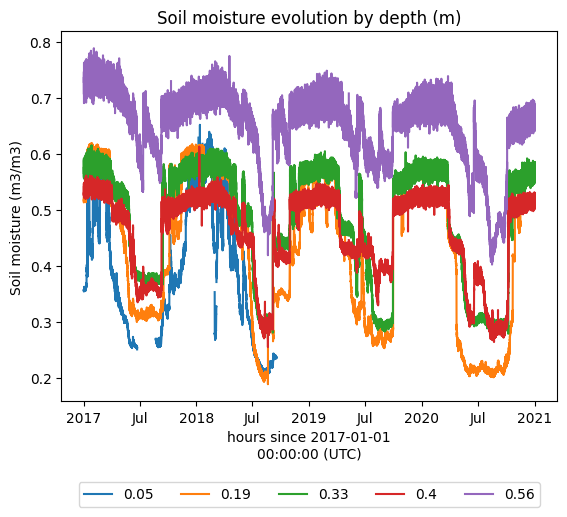

In [41]:
swc.sel(depth = swc.depth != 0.03).plot.line(x = 'time', hue="depth", add_legend=False)
ax = plt.gca()
ax.legend( 
    swc.depth.values[1::], 
    ncol=5,                     # horizontal layout
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2)
)
plt.title("Soil moisture evolution by depth (m)")
plt.ylabel("Soil moisture (m3/m3)")
plt.show()

In [42]:
# Initialise using the X*_{SURF/ROOT/DEEP} fields
iswc_surf = (swc.sel(depth = swc.depth <= 0.05, time=swc.time[0]).mean('depth') - 0.253) /(0.468-0.253)
iswc_root = (swc.sel(depth = swc.depth >= 0.05, time=swc.time[0]).mean('depth') - 0.253) / (0.468-0.253)
iswc_deep = (swc.sel(depth = swc.depth[-1], time=swc.time[0]) - 0.253) / (0.468-0.253)
print(iswc_surf, iswc_root, iswc_deep)

<xarray.DataArray 'TH03' ()> Size: 8B
array(0.23850878)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean <xarray.DataArray 'TH03' ()> Size: 8B
array(1.33235298)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean <xarray.DataArray 'TH03' ()> Size: 4B
array(2.212519, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2017-01-01
    depth    float64 8B 0.56
Attributes:
    units:         m3 m-3
    long_name:     Soil water content at 0.03 m depth Campbell calibration
    cell_methods:  time: mean


In [31]:
base = xr.open_dataset('../../RUNS/Cabauw/BASECABAUW/output/SURF_ATM_DIAGNOSTICS.OUT.nc', decode_times=False)
base['Q2M'] #Diagnostics variables T2M, Q2M, W10M

<xarray.DataArray 'Q2M' (time: 20447, lat: 1, lon: 1)> Size: 164kB
[20447 values with dtype=float64]
Coordinates:
  * time     (time) float64 164kB 30.0 60.0 90.0 ... 6.134e+05 6.134e+05
  * lat      (lat) float64 8B 51.98
  * lon      (lon) float64 8B 4.925
Attributes:
    long_name:     X_Y_Q2M
    units:         KG/KG
    grid_mapping:  Projection_Type

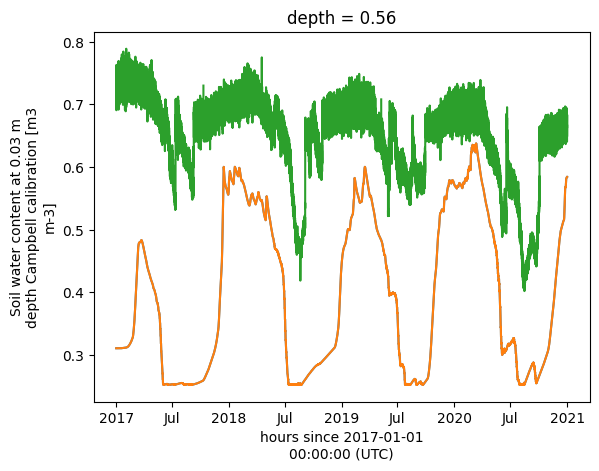

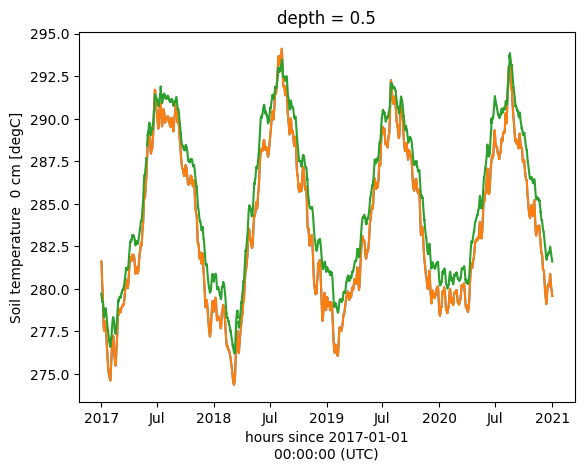

In [89]:
base_data['WG6_ISBA'].plot()
x_data['WG6_ISBA'].plot()
swc.sel(depth = .56).plot()

plt.show()

base_data['TG6_ISBA'].plot()
x_data['TG6_ISBA'].plot()
(temp.sel(depth = .5) + 273.15).plot()
plt.show()

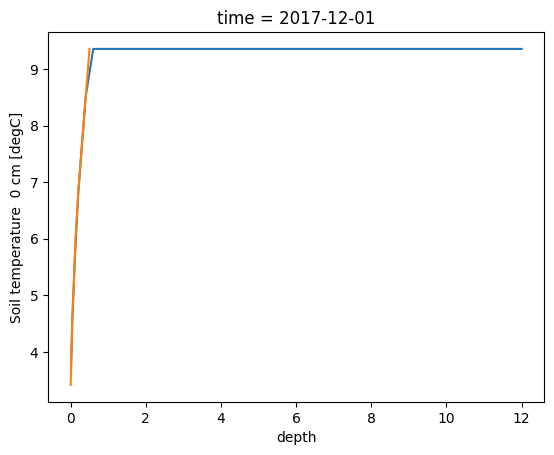

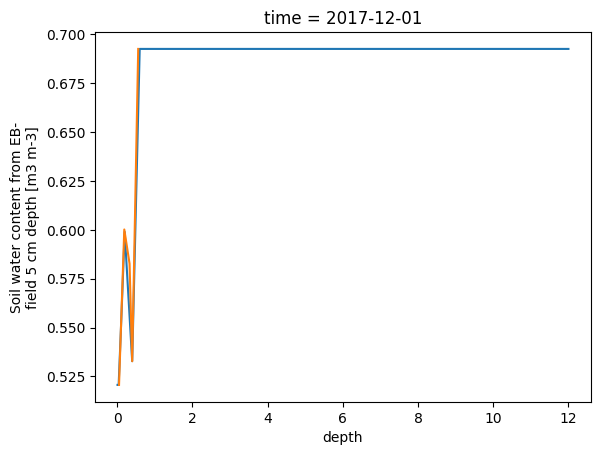

In [166]:
#Simple approach Linear interpolation + Constant outside the interval (just for initialization, not good for validation)
XSOILGRID = [0.01,0.04,0.10,0.20,0.40,0.60,0.80,1.00,1.50,2.00,3.00,5.00,8.00,12.0]
d_min = temp.depth.min()
d_max = temp.depth.max()
t_interp = temp.interp(depth=XSOILGRID, method = 'linear')
up_const = temp.sel(depth=d_min)
down_const = temp.sel(depth=d_max)
t_interp0 = t_interp.where(t_interp.depth <= d_max, down_const).where(t_interp.depth >= d_min, up_const).isel(time=0)
t_interp0.plot()
temp.isel(time = 0).plot()
plt.show()
swc_interp = swc.interp(depth=XSOILGRID, method = 'linear')
d_min = swc.depth.min()
d_max = swc.depth.max()
up_const = swc.sel(depth=d_min)
down_const = swc.sel(depth=d_max)
swc_interp0 = swc_interp.where(swc_interp.depth <= d_max, down_const).where(swc_interp.depth >= d_min, up_const).isel(time=0)
swc_interp0.plot()
swc.isel(time=0).plot()
plt.show()

In [168]:
t_interp0 + 273.15

<xarray.DataArray 'TS00' (depth: 14)> Size: 112B
array([276.8744519 , 277.63836136, 278.6530086 , 279.9549221 ,
       281.66715946, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:          degC
    long_name:      Soil temperature  0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean

In [213]:
fc = 0.468
wilt = 0.253
(swc_interp0 - wilt)/(fc - wilt)

<xarray.DataArray 'TH05' (depth: 14)> Size: 112B
array([1.24492156, 1.24492156, 1.37703803, 1.60903354, 1.30136383,
       2.04461296, 2.04461296, 2.04461296, 2.04461296, 2.04461296,
       2.04461296, 2.04461296, 2.04461296, 2.04461296])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content from EB-field 5 cm depth
    cell_methods:  time: mean

In [63]:
import sqlite3
with sqlite3.connect('/home/alvaro/master/TFM/OSVAS/sqlites/validation_data/Cabauw/OBSTABLE_2018.sqlite') as conn:
    cursor = conn.cursor()

In [82]:
with sqlite3.connect('/home/alvaro/master/TFM/OSVAS/sqlites/model_data/Cabauw/BASECABAUW/2018/01/FCTABLE_Q2m_201801_00.sqlite') as conn_model:
    cursor = conn_model.cursor()

In [83]:
import pandas as pd
df = pd.read_sql_query("SELECT * FROM SYNOP", conn)
df_model = pd.read_sql_query("SELECT * FROM FC", conn_model)

In [95]:
conn.close()
conn_model.close()